<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana5/CuadraturaGaussiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
import sympy as sym

In [3]:
x = sym.Symbol('x',real='True')
F = sym.cos(x)**2
F

cos(x)**2

In [5]:
sym.integrate(F,(x,-1.,1.))

1.45464871341284

In [7]:
f = lambda x: np.cos(x)**2

In [8]:
W = np.array([1.,1.])
X = np.array([-1/np.sqrt(3),1/np.sqrt(3)])
I = np.sum(W*f(X))
I

np.float64(1.4041924619823274)

In [19]:
ROOTS,WEIGHTS = np.polynomial.legendre.leggauss(10)
ROOTS

array([-0.97390653, -0.86506337, -0.67940957, -0.43339539, -0.14887434,
        0.14887434,  0.43339539,  0.67940957,  0.86506337,  0.97390653])

In [37]:
sum(ROOTS)

np.float64(3.3306690738754696e-16)

In [20]:
WEIGHTS

array([0.06667134, 0.14945135, 0.21908636, 0.26926672, 0.29552422,
       0.29552422, 0.26926672, 0.21908636, 0.14945135, 0.06667134])

In [38]:
sum(WEIGHTS)

np.float64(2.0)

In [21]:
I = np.sum(WEIGHTS*f(ROOTS))
I

np.float64(1.4546487134128407)

In [22]:
sym.integrate(F,(x,-1.,1.))

1.45464871341284

In [23]:
sym.integrate(F,(x,0,sym.pi))

pi/2

In [24]:
a = 0
b = np.pi

In [27]:
I = 0.5*(b-a)*np.sum(WEIGHTS*f(0.5*(ROOTS*(b-a) + a + b)))
I

np.float64(1.5707963267949032)

In [30]:
# Necesitamos una familia de polinomios ortogonales en -1,1
def GetLegendre(n):

  x = sym.Symbol('x',Real=True)
  #y = sym.Symbol('y',Real=True)

  y = (x**2 - 1)**n

  poly = sym.diff(y,x,n)/(2**n * factorial(n))

  return poly

In [75]:
Legendre = GetLegendre(20)
Legendre

1.0*x**20 + 95.0*x**18*(x**2 - 1) + 1816.875*x**16*(x**2 - 1)**2 + 12112.5*x**14*(x**2 - 1)**3 + 34444.921875*x**12*(x**2 - 1)**4 + 45467.296875*x**10*(x**2 - 1)**5 + 28417.060546875*x**8*(x**2 - 1)**6 + 8119.16015625*x**6*(x**2 - 1)**7 + 951.464080810547*x**4*(x**2 - 1)**8 + 35.2394104003906*x**2*(x**2 - 1)**9 + 0.176197052001953*(x**2 - 1)**10

In [76]:
x = sym.Symbol('x',Real=True)
DLegendre= sym.diff(Legendre,x,1)
DLegendre

210.0*x**19 + 8977.5*x**17*(x**2 - 1) + 101745.0*x**15*(x**2 - 1)**2 + 445134.375*x**13*(x**2 - 1)**3 + 868012.03125*x**11*(x**2 - 1)**4 + 795677.6953125*x**9*(x**2 - 1)**5 + 341004.7265625*x**7*(x**2 - 1)**6 + 63938.3862304688*x**5*(x**2 - 1)**7 + 4440.16571044922*x**3*(x**2 - 1)**8 + 74.0027618408203*x*(x**2 - 1)**9

In [77]:
LegendreNumpy  = sym.lambdify([x],Legendre,'numpy')
DLegendreNumpy = sym.lambdify([x],DLegendre,'numpy')

In [78]:
def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-14):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

In [79]:


def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-13):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

def GetAllRoots(f, df, x, tolerancia_decimales=8, tol_unicidad=1e-10):

    Roots = []

    for x0 in x:

        root = GetNewtonMethod(f, df, x0)

        if root is not False:

            # Redondeamos
            croot = np.round(root, tolerancia_decimales)

            # Verificamos que no esté ya (con tolerancia)
            if not any(np.isclose(croot, r, atol=tol_unicidad) for r in Roots):
                Roots.append(croot)

    Roots = np.array(Roots)
    Roots.sort()

    return Roots

In [80]:
x = sym.Symbol('x',Real=True)
F = sym.cos(10*x)*sym.exp(-0.9*x)
#F = x**3 - x**4 + 2*x**2 + 2*x + 1
F

exp(-0.9*x)*cos(10*x)

In [81]:
DF = sym.diff(F,x)
DF

-10*exp(-0.9*x)*sin(10*x) - 0.9*exp(-0.9*x)*cos(10*x)

In [82]:
# Funcion en numpy
Fn = sym.lambdify([x],F,'numpy')
DFn = sym.lambdify([x],DF,'numpy')

In [83]:
xi = np.linspace(-1,1,100,dtype=np.longdouble)
roots = GetAllRoots(LegendreNumpy,DLegendreNumpy,xi)
roots

array([-0.9931286 , -0.96397193, -0.91223443, -0.83911697, -0.74633191,
       -0.63605368, -0.510867  , -0.37370609, -0.22778585, -0.07652652,
        0.07652652,  0.22778585,  0.37370609,  0.510867  ,  0.63605368,
        0.74633191,  0.83911697,  0.91223443,  0.96397193,  0.9931286 ],
      dtype=float128)

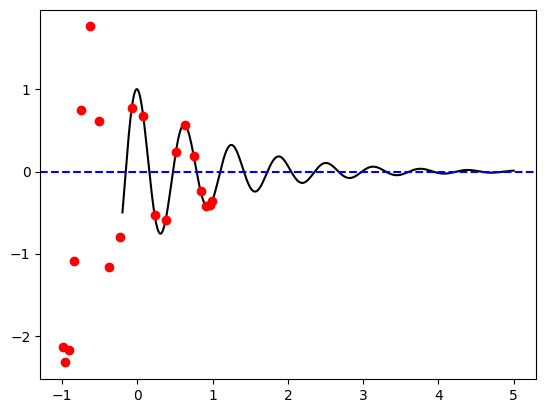

In [84]:
xj = np.linspace(-0.2,5,1000,dtype=np.longdouble)
plt.plot(xj,Fn(xj),color='k')
plt.plot(roots,Fn(roots),'o',color='r')
plt.axhline(0,linestyle='--',color='b')
#plt.xscale('log')

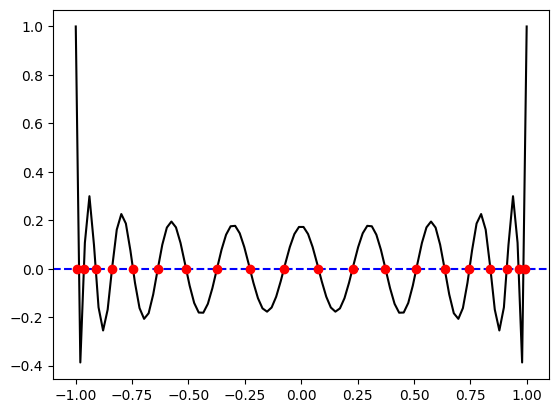

In [85]:
xj = np.linspace(-1,1,100,dtype=np.longdouble)
plt.plot(xj,LegendreNumpy(xj),color='k')
plt.axhline(0,linestyle='--',color='b')
plt.plot(roots,LegendreNumpy(roots),'o',color='r')